In [1]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv('/content/cleaned_data_day1.csv')

df.head()

,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,purchase_year,purchase_month,purchase_day,desc_length,subject_length
0,32,Other,GoPro Hero,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,2021,3,22,284,13
1,42,Female,LG Smart TV,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,2021,5,22,282,24
2,48,Other,Dell XPS,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,2020,7,14,275,15
3,27,Female,Microsoft Office,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,2020,11,13,262,14
4,67,Female,Autodesk AutoCAD,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,2020,2,4,333,9


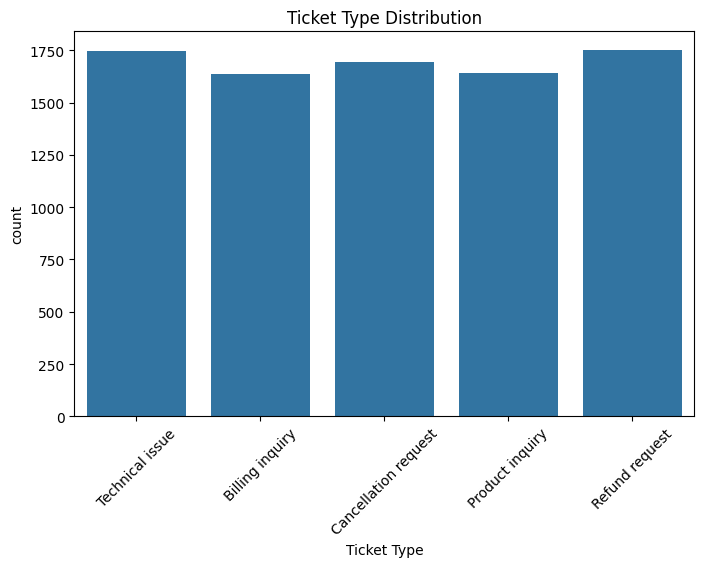

In [2]:
# 📊 Step 3: Ticket Type Distribution Analysis
# In this step, we visualize the distribution of different ticket types
# such as Technical Issue, Billing Inquiry, Account Issue, and Product Inquiry.
# This helps us understand class balance in the dataset.
# Identifying imbalance is important because it can affect model performance,
# especially in classification tasks. If one class dominates,
# the model may become biased toward that class.
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot
plt.figure(figsize=(8,5))
sns.countplot(x='Ticket Type', data=df)
plt.title('Ticket Type Distribution')
plt.xticks(rotation=45)
plt.show()

In [3]:

# 📊 Step 4: Ticket Type Count Analysis
# This step calculates the exact number of tickets in each category.
# It helps confirm whether the dataset is balanced or imbalanced.
df['Ticket Type'].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


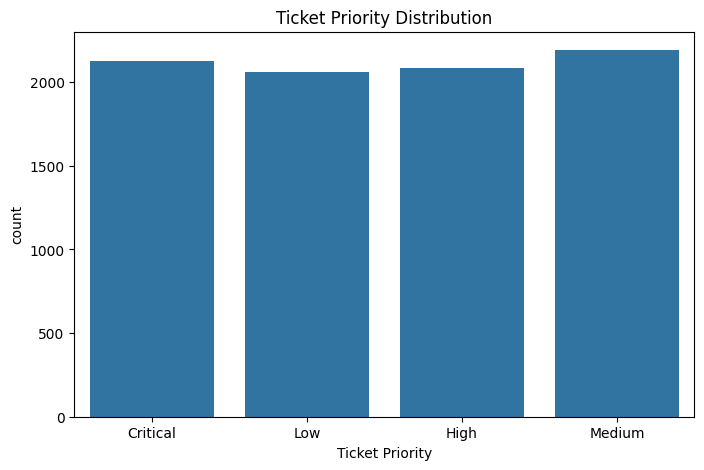

In [4]:
# 📊 Step 5: Ticket Priority Distribution Analysis
# In this step, we visualize the distribution of ticket priorities
# such as Low, Medium, High, and Critical.
# This helps us understand whether the dataset is balanced across priority levels.
# Identifying imbalance is important because it affects model performance,
# especially for predicting high-priority (critical) tickets.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Ticket Priority', data=df)
plt.title('Ticket Priority Distribution')
plt.show()

In [5]:
# 📊 Step 6: Ticket Priority Count Analysis
# This step calculates the exact number of tickets in each priority category.
# It helps confirm whether the dataset is balanced or imbalanced.
# These values are useful for reporting and model evaluation.

df['Ticket Priority'].value_counts()

,count
Ticket Priority,
Medium,2192
Critical,2129
High,2085
Low,2063


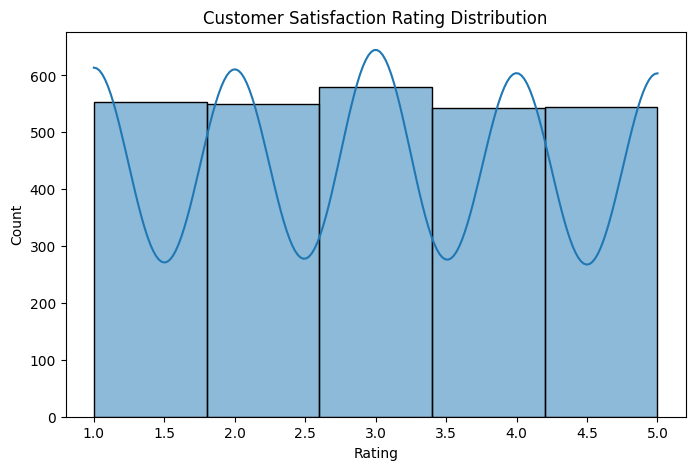

In [6]:
# 📊 Step 7: Customer Satisfaction Rating Distribution
# This step visualizes how customer satisfaction ratings are distributed.
# Ratings range from 1 to 5, where lower values indicate dissatisfaction.
# This helps identify customer experience trends and potential issues.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Customer Satisfaction Rating'].dropna(), bins=5, kde=True)
plt.title('Customer Satisfaction Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

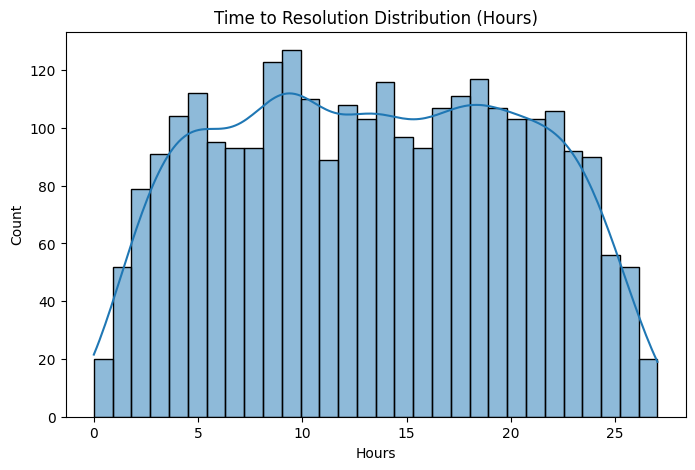

In [7]:
# 📊 Step 8: Time to Resolution Analysis
# This step visualizes how long it takes to resolve tickets.
# It helps understand the distribution of resolution times,
# which is important for building a regression model.

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to datetime first (IMPORTANT)
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

# Extract resolution hours
resolution_hours = (df['Time to Resolution'] - df['Time to Resolution'].min()).dt.total_seconds() / 3600

plt.figure(figsize=(8,5))
sns.histplot(resolution_hours.dropna(), bins=30, kde=True)
plt.title('Time to Resolution Distribution (Hours)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

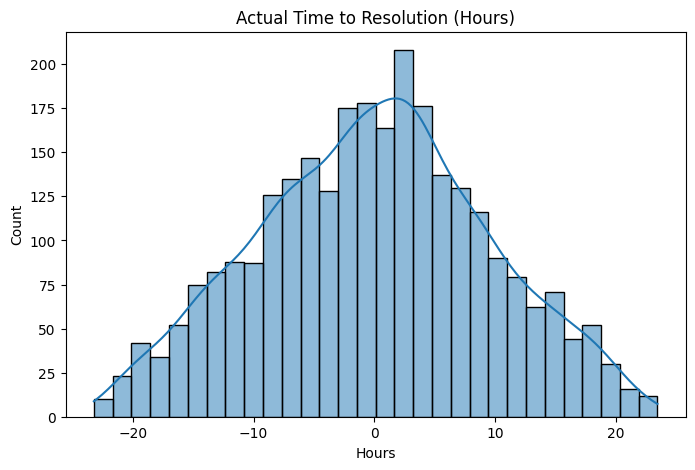

In [8]:
# 📊 Step 8 (Corrected): Time to Resolution Analysis
# This step calculates actual resolution time using:
# (Time to Resolution - First Response Time)
# and visualizes its distribution.

# Convert to datetime
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

# Calculate resolution hours correctly
resolution_hours = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(resolution_hours.dropna(), bins=30, kde=True)
plt.title('Actual Time to Resolution (Hours)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

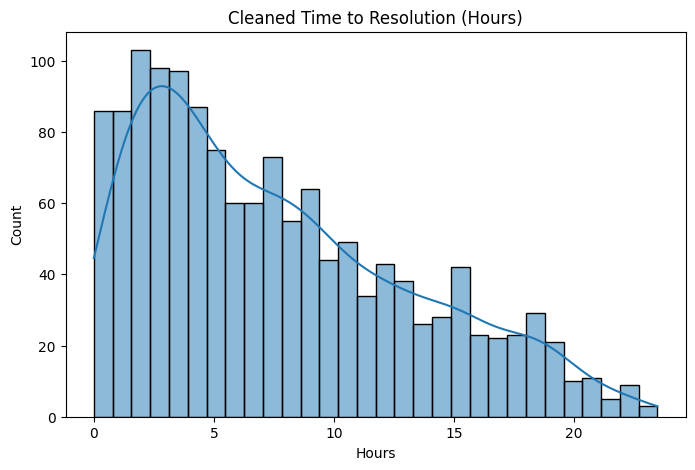

In [9]:
# 📊 Step 8 (Final Cleaned): Time to Resolution Analysis
# This step removes invalid negative values and visualizes correct resolution time.

# Convert to datetime
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')

# Calculate resolution hours
resolution_hours = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600

# Remove negative values
resolution_hours = resolution_hours[resolution_hours >= 0]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(resolution_hours.dropna(), bins=30, kde=True)
plt.title('Cleaned Time to Resolution (Hours)')
plt.xlabel('Hours')
plt.ylabel('Count')
plt.show()

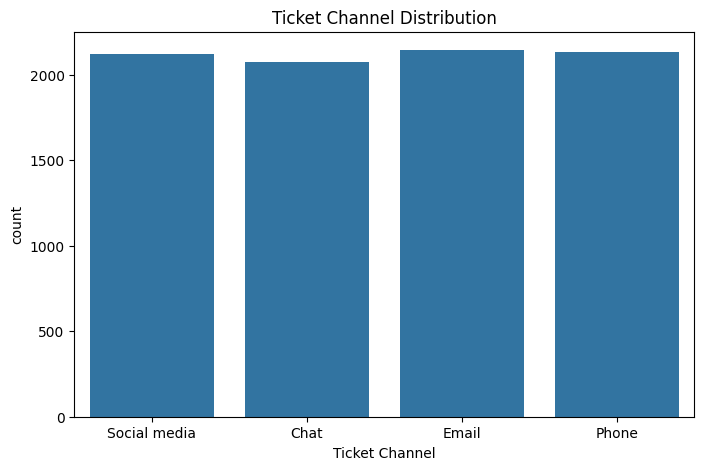

In [10]:
# 📊 Step 9: Ticket Channel Distribution Analysis
# This step analyzes how tickets are distributed across different channels
# such as Email, Chat, Social Media, and Phone.
# This helps understand which channel receives the most support requests.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Ticket Channel', data=df)
plt.title('Ticket Channel Distribution')
plt.show()

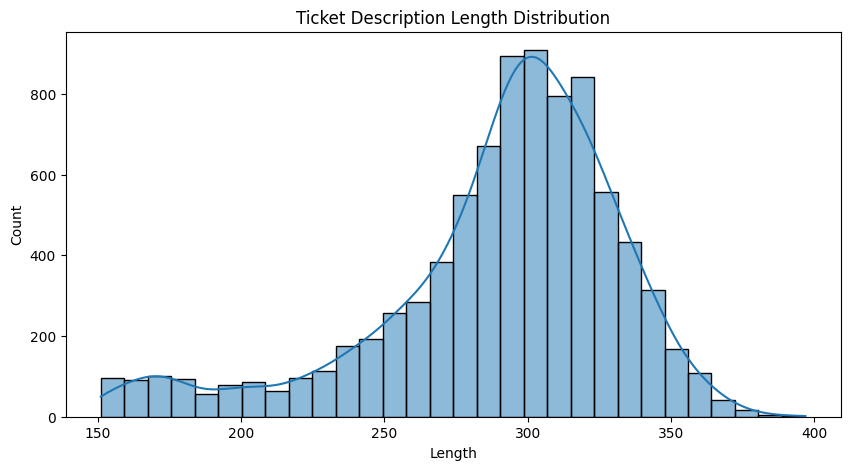

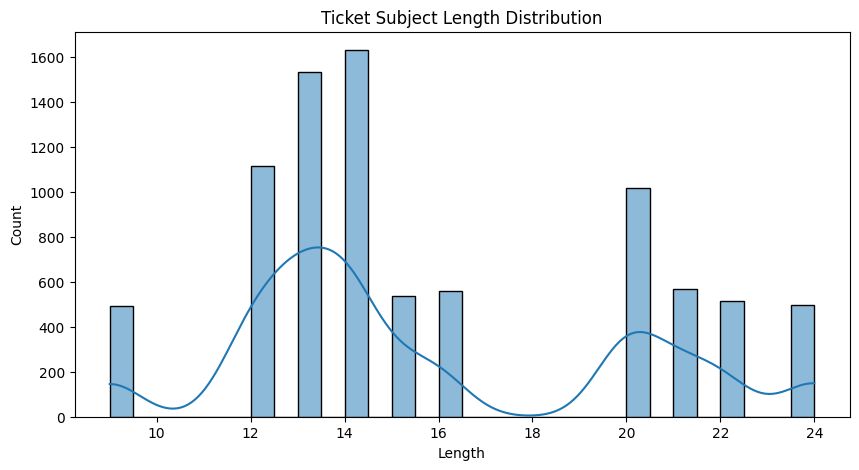

In [11]:
# 📊 Step (Final): Text Length Distribution
# This step visualizes the length of ticket descriptions and subjects.
# It helps understand how long customer queries are,
# which is important for NLP model performance.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['desc_length'], bins=30, kde=True)
plt.title('Ticket Description Length Distribution')
plt.xlabel('Length')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['subject_length'], bins=30, kde=True)
plt.title('Ticket Subject Length Distribution')
plt.xlabel('Length')
plt.show()